# MH → SAMC: Two Lines for a Huge Improvement

This notebook shows that SAMC is just MH with a weight correction.
We start with a standard Metropolis-Hastings loop, then add **two lines**
to get SAMC — and show the difference is dramatic.

**Problem:** 2D multimodal energy landscape with many local basins (same as `benchmarks/vs_mh_pt.py`).
At low temperature (T=0.1), MH gets trapped. SAMC escapes.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch

from illuma_samc import GainSequence, SAMCWeights, UniformPartition
from illuma_samc.problems.multimodal_2d import energy_fn

## Setup

Same energy function, same proposal, same temperature, same number of steps.

In [2]:
# Settings aligned with benchmarks/vs_mh_pt.py (2D multimodal)
T = 0.1  # low temperature — makes MH struggle
N_STEPS = 500_000  # same as benchmark
PROPOSAL_STD = 0.05  # same as benchmark
SEED = 42


# Energy wrapper (scalar in, scalar out)
def E(x):
    e, in_region = energy_fn(x)
    return float(e), bool(in_region)


# Partition for SAMC (same as benchmark: 42 bins, e_min=-8.2, e_max=0.0)
partition = UniformPartition(e_min=-8.2, e_max=0.0, n_bins=42)
gain = GainSequence("ramp", rho=1.0, tau=1.0, warmup=1, step_scale=1000)

## Standard MH

This is the baseline. Nothing fancy — propose, accept/reject, repeat.

In [3]:
torch.manual_seed(SEED)
x = torch.zeros(2)
fx, _ = E(x)

mh_samples = []
mh_energies = []
mh_accept = 0

for t in range(1, N_STEPS + 1):
    x_new = x + PROPOSAL_STD * torch.randn(2)
    fy, in_region = E(x_new)

    log_r = (-fy + fx) / T

    if in_region and (log_r > 0 or math.log(torch.rand(1).item() + 1e-300) < log_r):
        x, fx = x_new.clone(), fy
        mh_accept += 1

    mh_energies.append(fx)
    if t % 100 == 0:
        mh_samples.append(x.clone())

mh_samples = torch.stack(mh_samples)
mh_energies = torch.tensor(mh_energies)
print(f"MH  — accept: {mh_accept / N_STEPS:.3f}, best E: {min(mh_energies):.3f}")

MH  — accept: 0.047, best E: -8.125


## MH + SAMC (add two lines)

Same loop. Same proposal. Same temperature. Two additions marked with `# ← SAMC`.

In [4]:
torch.manual_seed(SEED)
x = torch.zeros(2)
fx, _ = E(x)

wm = SAMCWeights(partition=partition, gain=gain)  # ← SAMC: init weights

samc_samples = []
samc_energies = []
samc_accept = 0

for t in range(1, N_STEPS + 1):
    x_new = x + PROPOSAL_STD * torch.randn(2)
    fy, in_region = E(x_new)

    log_r = (-fy + fx) / T + wm.correction(fx, fy)  # ← SAMC: add correction

    if in_region and (log_r > 0 or math.log(torch.rand(1).item() + 1e-300) < log_r):
        x, fx = x_new.clone(), fy
        samc_accept += 1

    wm.step(t, fx)  # ← SAMC: update weights
    samc_energies.append(fx)
    if t % 100 == 0:
        samc_samples.append(x.clone())

samc_samples = torch.stack(samc_samples)
samc_energies = torch.tensor(samc_energies)
print(f"SAMC — accept: {samc_accept / N_STEPS:.3f}, best E: {min(samc_energies):.3f}")

SAMC — accept: 0.436, best E: -8.125


## Diagnostics

### 1. Energy Traces

MH flatlines (trapped). SAMC oscillates across the full energy range (mixing).

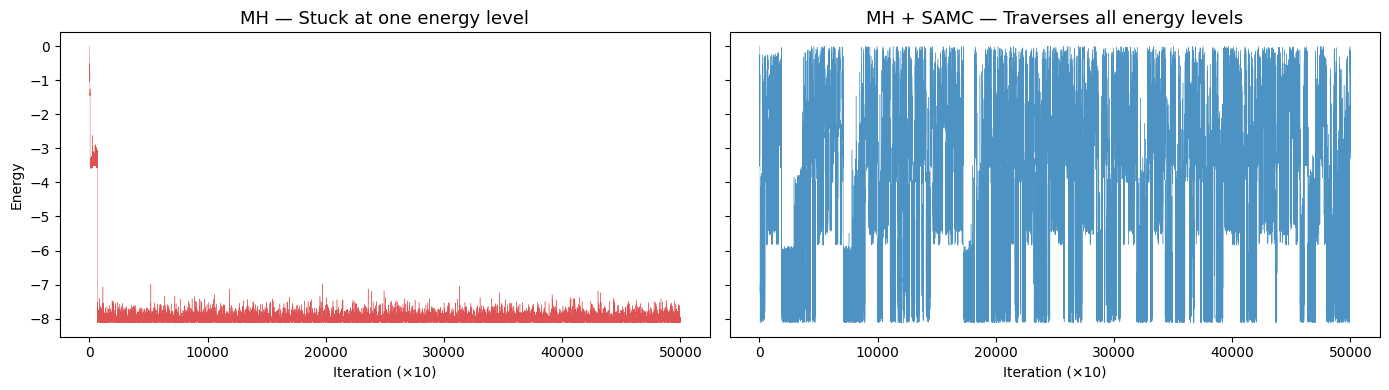

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

axes[0].plot(mh_energies[::10].numpy(), lw=0.3, alpha=0.8, color="tab:red")
axes[0].set_title("MH — Stuck at one energy level", fontsize=13)
axes[0].set_xlabel("Iteration (×10)")
axes[0].set_ylabel("Energy")

axes[1].plot(samc_energies[::10].numpy(), lw=0.3, alpha=0.8, color="tab:blue")
axes[1].set_title("MH + SAMC — Traverses all energy levels", fontsize=13)
axes[1].set_xlabel("Iteration (×10)")

plt.tight_layout()
plt.show()

### 2. Sample Traces in Domain Space

MH explores a tiny region. SAMC covers the full domain.

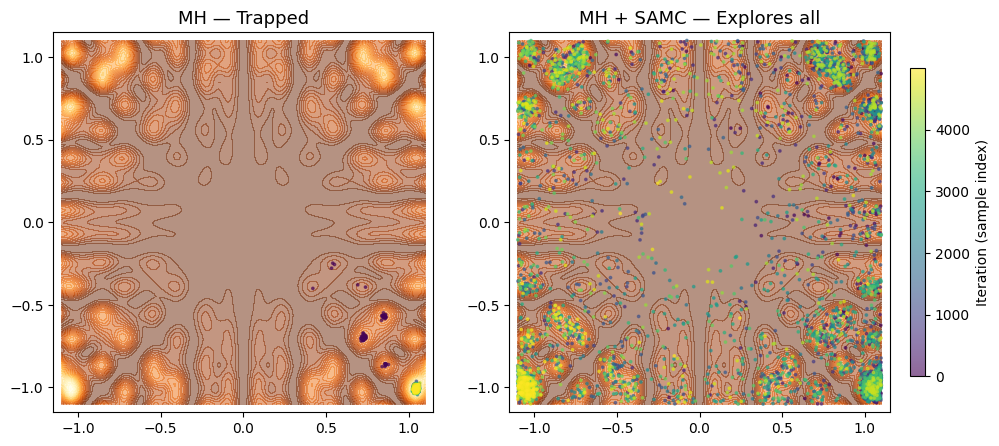

In [6]:
# Energy landscape background
grid = torch.linspace(-1.1, 1.1, 200)
X, Y = torch.meshgrid(grid, grid, indexing="ij")
Z_flat = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=1)
E_grid, _ = energy_fn(Z_flat)
E_grid = E_grid.reshape(200, 200).numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, samples, title in [
    (axes[0], mh_samples, "MH — Trapped"),
    (axes[1], samc_samples, "MH + SAMC — Explores all"),
]:
    ax.contourf(X.numpy(), Y.numpy(), E_grid, levels=30, cmap="YlOrBr", alpha=0.5)
    sc = ax.scatter(
        samples[:, 0].numpy(),
        samples[:, 1].numpy(),
        c=range(len(samples)),
        cmap="viridis",
        s=3,
        alpha=0.6,
    )
    ax.set_title(title, fontsize=13)
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.set_aspect("equal")

fig.colorbar(sc, ax=axes, shrink=0.8, pad=0.02, label="Iteration (sample index)")
plt.show()

### 3. Flat Density in Energy Space

SAMC's whole point: visit every energy level uniformly.
Compare the bin visit histogram for MH (spiky) vs SAMC (flat).

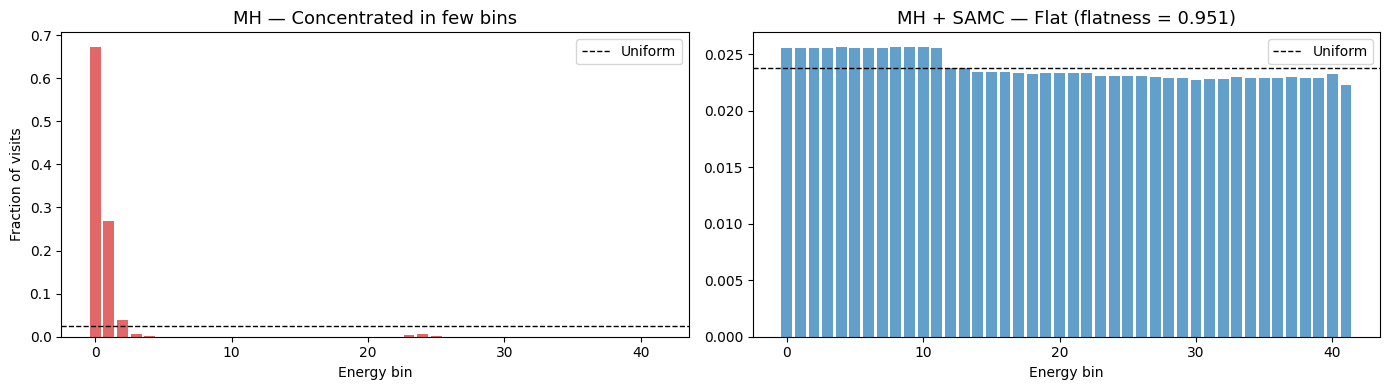

SAMC bin visit flatness: 0.951 (1.0 = perfect)


In [7]:
# Bin MH energies using the same partition
edges = partition.edges.numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

# MH bin visits
mh_counts_np = np.histogram(mh_energies.numpy(), bins=edges)[0].astype(float)
mh_counts_np /= max(mh_counts_np.sum(), 1)
axes[0].bar(range(len(mh_counts_np)), mh_counts_np, color="tab:red", alpha=0.7)
axes[0].axhline(1.0 / len(mh_counts_np), color="k", ls="--", lw=1, label="Uniform")
axes[0].set_title("MH — Concentrated in few bins", fontsize=13)
axes[0].set_xlabel("Energy bin")
axes[0].set_ylabel("Fraction of visits")
axes[0].legend()

# SAMC bin visits
samc_counts_np = wm.counts.numpy()
samc_counts_np = samc_counts_np / max(samc_counts_np.sum(), 1)
axes[1].bar(range(len(samc_counts_np)), samc_counts_np, color="tab:blue", alpha=0.7)
axes[1].axhline(1.0 / len(samc_counts_np), color="k", ls="--", lw=1, label="Uniform")
axes[1].set_title(f"MH + SAMC — Flat (flatness = {wm.flatness():.3f})", fontsize=13)
axes[1].set_xlabel("Energy bin")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"SAMC bin visit flatness: {wm.flatness():.3f} (1.0 = perfect)")

### 4. Reweighting SAMC Samples to the Target Distribution

SAMC samples from a *flat* distribution (proportional to $\exp(-E/T - \theta_k)$).
To recover the original target $\exp(-E/T)$, use binary rejection sampling:

$$p_{\text{keep}}(i) = \frac{\exp(\theta_{k_i})}{\max_j \exp(\theta_{k_j})}$$

Each sample is independently kept with probability $p_{\text{keep}}$ or discarded.
The surviving subset is an unweighted draw from the target distribution.

In [8]:
# Compute importance weights and resample via binary rejection
sample_energies = torch.tensor([float(energy_fn(s)[0]) for s in samc_samples])
weights = wm.importance_weights(sample_energies)
torch.manual_seed(0)
resampled = wm.resample(samc_samples, sample_energies)

print(f"SAMC flat samples: {len(samc_samples)}")
print(f"Kept after rejection: {len(resampled)} ({len(resampled) / len(samc_samples) * 100:.1f}%)")
print(f"Effective sample size: {1.0 / (weights**2).sum().item():.0f} / {len(weights)}")

SAMC flat samples: 5000
Kept after rejection: 205 (4.1%)
Effective sample size: 254 / 5000


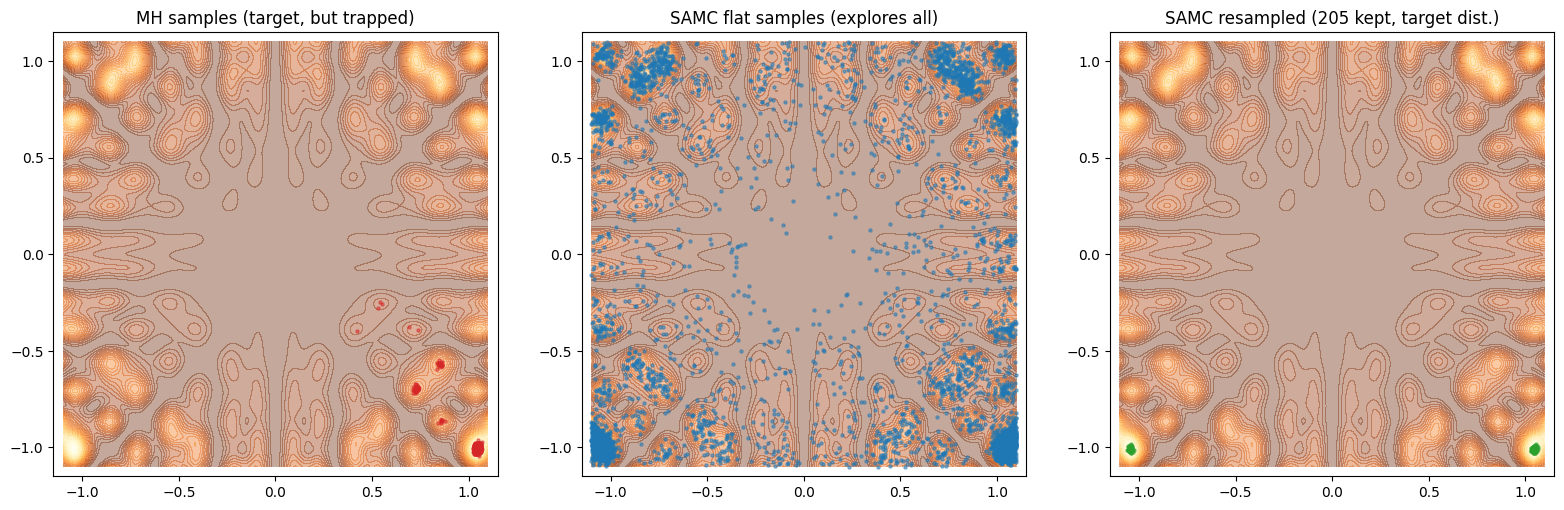

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# MH samples (already from target, but trapped)
axes[0].contourf(X.numpy(), Y.numpy(), E_grid, levels=30, cmap="YlOrBr", alpha=0.4)
axes[0].scatter(
    mh_samples[:, 0].numpy(),
    mh_samples[:, 1].numpy(),
    s=5,
    alpha=0.5,
    color="tab:red",
)
axes[0].set_title("MH samples (target, but trapped)", fontsize=12)
axes[0].set_xlim(-1.15, 1.15)
axes[0].set_ylim(-1.15, 1.15)
axes[0].set_aspect("equal")

# SAMC raw samples (flat distribution — uniform exploration)
axes[1].contourf(X.numpy(), Y.numpy(), E_grid, levels=30, cmap="YlOrBr", alpha=0.4)
axes[1].scatter(
    samc_samples[:, 0].numpy(),
    samc_samples[:, 1].numpy(),
    s=5,
    alpha=0.5,
    color="tab:blue",
)
axes[1].set_title("SAMC flat samples (explores all)", fontsize=12)
axes[1].set_xlim(-1.15, 1.15)
axes[1].set_ylim(-1.15, 1.15)
axes[1].set_aspect("equal")

# SAMC resampled (binary rejection → unweighted target samples)
axes[2].contourf(X.numpy(), Y.numpy(), E_grid, levels=30, cmap="YlOrBr", alpha=0.4)
if len(resampled) > 0:
    axes[2].scatter(
        resampled[:, 0].numpy(),
        resampled[:, 1].numpy(),
        s=5,
        alpha=0.5,
        color="tab:green",
    )
axes[2].set_title(f"SAMC resampled ({len(resampled)} kept, target dist.)", fontsize=12)
axes[2].set_xlim(-1.15, 1.15)
axes[2].set_ylim(-1.15, 1.15)
axes[2].set_aspect("equal")

plt.tight_layout()
plt.show()

### 5. Summary

| | MH | MH + SAMC |
|---|---|---|
| Code change | — | +2 lines |
| Explores all energy levels | No (trapped) | Yes (flat histogram) |
| Can reweight to target | N/A | Yes (importance weights) |
| Extra cost per iteration | — | O(1) theta lookup + update |

In [10]:
print("=== Summary ===")
print(f"{'':20s} {'MH':>12s} {'MH + SAMC':>12s}")
print(f"{'Accept rate':20s} {mh_accept / N_STEPS:12.3f} {samc_accept / N_STEPS:12.3f}")
print(f"{'Best energy':20s} {mh_energies.min():12.3f} {samc_energies.min():12.3f}")
print(f"{'Bin flatness':20s} {'N/A':>12s} {wm.flatness():12.3f}")
print(f"{'Bins visited':20s} {(mh_counts_np > 0).sum():12d} {(wm.counts > 0).sum().item():12.0f}")
print(f"{'Extra code':20s} {'0 lines':>12s} {'2 lines':>12s}")

=== Summary ===
                               MH    MH + SAMC
Accept rate                 0.047        0.436
Best energy                -8.125       -8.125
Bin flatness                  N/A        0.951
Bins visited                   24           42
Extra code                0 lines      2 lines
